# Exploratory Data Analysis

This notebook explores the main patterns, distributions, relationships, and potential data issues in the analytical dataset before statistical modelling.

Main steps:
- Compare key indicators across Romanian counties
- Explore migration, agricultural employment, mechanization, productivity, and climate variables
- Examine preliminary correlations between the main variables
- Analyze temporal trends over the 2012–2022 period
- Inspect variable distributions, missing values, and potential outliers
- Compare the density-based and residual mechanization indices
- Explore relationships between agricultural employment and mechanization
- Assess potential multicollinearity using Variance Inflation Factors (VIF)

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("../../data/processed/analysis_dataset_eurostat.csv")
df.head(2)

,an,judet,emig_masc_nr,emig_fem_nr,emigranti_total_nr,emig_15_64_nr,imig_masc_nr,imig_fem_nr,imigranti_total_nr,imigranti_15_64_nr,...,migratie_neta_15_64_nr,rata_migratie_neta_15_64,ocupati_aff_eurostat_mii,ocupati_total_eurostat_mii,ocupati_aff_eurostat_nr,ocupati_total_eurostat_nr,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,schimbare_ocupati_aff_eurostat_pct,ocupati_aff_eurostat_thousand
0,2012,Alba,143,144,287,222,43,33,76,66,...,-156,-0.679031,28.85,130.90,28850.0,130900.0,22.039725,NaN,NaN,28.85
1,2013,Alba,104,158,262,224,53,41,94,83,...,-141,-0.618020,30.38,131.94,30380.0,131940.0,23.025618,0.985893,5.303293,30.38


###
COUNTY-LEVEL EDA

In [6]:

county_vars = [
    "rata_emig_15_64",
    "rata_imig_15_64",
    "rata_migratie_neta_15_64",
    "intensitate_migratie",
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",
    "yield_grau",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]

#medie judet pe toate perioada
county_summary = (
    df.groupby("judet")[county_vars]
    .mean()
    .round(3)
)

county_summary.head()

,rata_emig_15_64,rata_imig_15_64,rata_migratie_neta_15_64,intensitate_migratie,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,indice_mecanizare_densitate,indice_mecanizare_rezidual,yield_grau,yield_porumb_boabe,yield_floarea_soarelui,yield_rapita,temperatura_medie_anuala_C,precipitatii_anuale_mm,pondere_rurala
judet,,,,,,,,,,,,,,,
Alba,1.290,0.481,-0.809,1.353,18.150,-0.131,0.316,0.317,4.057,5.346,2.233,2.434,9.103,910.431,41.605
Arad,1.665,0.532,-1.133,1.796,12.321,-1.174,-0.403,0.949,4.613,5.072,2.499,2.789,11.812,774.052,44.968
Arges,0.783,0.264,-0.520,0.824,14.701,-0.934,-0.212,0.385,3.442,4.073,2.024,2.118,9.348,877.920,54.100
Bacau,2.049,3.155,1.106,3.893,41.457,-0.911,-0.488,-0.543,3.494,4.666,2.120,1.970,9.104,716.534,56.999
Bihor,0.782,0.359,-0.423,0.924,21.422,-0.905,-0.030,1.798,3.830,5.104,2.003,2.101,10.894,823.217,51.181


In [7]:
#top emigrare
county_summary["rata_emig_15_64"].sort_values(ascending=False).head(10)

judet
Vaslui           2.646
Iasi             2.628
Caras-Severin    2.462
Galati           2.386
Sibiu            2.190
Timis            2.142
Bacau            2.049
Brasov           2.033
Hunedoara        1.891
Neamt            1.796
Name: rata_emig_15_64, dtype: float64

In [8]:
#bottom emigrare
county_summary["rata_emig_15_64"].sort_values(ascending=True).head(10)

judet
Harghita     0.509
Ilfov        0.613
Gorj         0.622
Covasna      0.626
Bihor        0.782
Arges        0.783
Giurgiu      0.786
Valcea       0.837
Salaj        0.857
Mehedinti    0.860
Name: rata_emig_15_64, dtype: float64

### County-level Emigration Patterns

- **Moldova and south-eastern counties with relatively high emigration:** Vaslui, Iași, Galați, Bacău, and Neamț.
- **More urbanized counties or counties characterized by higher international mobility:** Timiș, Brașov, and Sibiu.
- **Counties affected by demographic and industrial decline:** Caraș-Severin and Hunedoara.

In [9]:
# top AFF

county_summary["pondere_ocupati_aff_eurostat"].sort_values(ascending=False).head(10)

judet
Vaslui       61.744
Ialomita     53.862
Neamt        52.923
Calarasi     50.294
Olt          48.060
Botosani     46.883
Teleorman    45.547
Suceava      45.261
Mehedinti    44.768
Bacau        41.457
Name: pondere_ocupati_aff_eurostat, dtype: float64

In [10]:
#bottom AFF
county_summary["pondere_ocupati_aff_eurostat"].sort_values(ascending=True).head(10)

judet
Ilfov         4.877
Sibiu         8.075
Hunedoara    10.624
Timis        10.645
Mures        10.695
Brasov       11.233
Cluj         11.428
Arad         12.321
Galati       14.015
Arges        14.701
Name: pondere_ocupati_aff_eurostat, dtype: float64

- **Top:** Counties with a stronger agricultural and rural structure.
- **Bottom:** Predominantly more urbanized counties.

In [11]:
# top index mecanizare densitate
county_summary["indice_mecanizare_densitate"].sort_values(ascending=False).head(10)

judet
Maramures          2.921
Harghita           2.189
Hunedoara          1.738
Brasov             1.730
Salaj              1.342
Sibiu              0.938
Caras-Severin      0.929
Covasna            0.650
Bistrita-Nasaud    0.378
Cluj               0.361
Name: indice_mecanizare_densitate, dtype: float64

In [12]:
#bottom index mecanizare densitate

county_summary["indice_mecanizare_densitate"].sort_values(ascending=True).head(10)

judet
Braila      -0.882
Buzau       -0.873
Constanta   -0.866
Ialomita    -0.857
Galati      -0.849
Tulcea      -0.836
Prahova     -0.747
Calarasi    -0.738
Botosani    -0.693
Vaslui      -0.684
Name: indice_mecanizare_densitate, dtype: float64

### Interpreting the Machinery Density Index

The machinery density index should be interpreted with caution:

- **Top:** Counties with relatively smaller cultivated areas tend to rank higher.
- **Bottom:** Large agricultural counties tend to rank lower.

This pattern suggests that machinery density per 1,000 hectares may be influenced by the size of the cultivated area.

In [13]:
#top index mecanizare - rezidual

county_summary["indice_mecanizare_rezidual"].sort_values(ascending=False).head(10)

judet
Bihor        1.798
Timis        1.167
Mures        1.157
Dolj         1.111
Olt          1.092
Arad         0.949
Satu Mare    0.905
Maramures    0.875
Teleorman    0.782
Dambovita    0.627
Name: indice_mecanizare_rezidual, dtype: float64

In [14]:
#bottom index mecanizare - rezidual

county_summary["indice_mecanizare_rezidual"].sort_values(ascending=True).head(10)

judet
Ilfov             -1.886
Prahova           -1.732
Tulcea            -1.271
Buzau             -1.165
Braila            -1.162
Bistrita-Nasaud   -1.144
Galati            -1.076
Ialomita          -0.805
Neamt             -0.737
Vaslui            -0.550
Name: indice_mecanizare_rezidual, dtype: float64

### Residual Mechanization Index

The residual-based index provides a more plausible measure of relative machinery endowment after adjusting for cultivated area.

- Agricultural and commercially oriented counties become more prominent among the highly mechanized counties.

In [15]:
#top yield porumb
county_summary["yield_porumb_boabe"].sort_values(ascending=False).head(10)

judet
Ialomita     6.125
Calarasi     5.953
Braila       5.875
Neamt        5.793
Timis        5.636
Mures        5.481
Satu Mare    5.425
Alba         5.346
Giurgiu      5.200
Bihor        5.104
Name: yield_porumb_boabe, dtype: float64

In [16]:
#bottom yield porumb
county_summary["yield_porumb_boabe"].sort_values(ascending=True).head(10)

judet
Vaslui             3.476
Vrancea            3.702
Galati             3.832
Dambovita          3.842
Tulcea             3.970
Iasi               4.014
Bistrita-Nasaud    4.024
Constanta          4.035
Caras-Severin      4.059
Arges              4.073
Name: yield_porumb_boabe, dtype: float64

### Agricultural Productivity Patterns

- Several high-yield counties are located in the south, south-east, and west of Romania. Interestingly, some counties with relatively low machinery density, such as Ialomița, Călărași, and Brăila, show high maize yields. This suggests that machinery density per 1,000 hectares does not necessarily correspond to higher agricultural productivity.

- Vaslui emerges as a potentially vulnerable county, combining relatively high emigration, a high share of agricultural employment, low mechanization, and low maize yields.

### Preliminary Correlation Matrix

In [17]:
#CORR RELATII PRINCIAPLE

corr_main_vars = [
    # Migration
    "rata_emig_15_64",
    "rata_migratie_neta_15_64",

    # Labour
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",

    # Mechanization
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",

    # Productivity / yields
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "yield_soia_boabe",

    # Climate changes
    "schimbare_temp_anuala_C",
    "schimbare_precipitatii_anuala_mm"
]

corr_main = df[corr_main_vars].corr().round(2)
corr_main

,rata_emig_15_64,rata_migratie_neta_15_64,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,indice_mecanizare_densitate,indice_mecanizare_rezidual,yield_grau,yield_orz_orzoaica,yield_porumb_boabe,yield_floarea_soarelui,yield_rapita,yield_soia_boabe,schimbare_temp_anuala_C,schimbare_precipitatii_anuala_mm
rata_emig_15_64,1.00,0.24,-0.09,0.11,-0.02,-0.06,0.18,0.19,0.05,0.10,0.09,0.03,0.01,-0.29
rata_migratie_neta_15_64,0.24,1.00,0.36,0.05,-0.19,-0.17,-0.10,-0.17,-0.04,0.02,-0.17,-0.08,0.01,-0.00
pondere_ocupati_aff_eurostat,-0.09,0.36,1.00,-0.08,-0.42,-0.14,-0.12,-0.04,-0.06,-0.07,-0.16,-0.00,0.07,0.08
schimbare_pondere_ocupati_aff_eurostat,0.11,0.05,-0.08,1.00,0.11,-0.03,0.06,-0.01,0.22,0.22,-0.00,0.12,-0.06,0.05
indice_mecanizare_densitate,-0.02,-0.19,-0.42,0.11,1.00,0.40,-0.10,-0.27,-0.05,-0.06,0.01,-0.12,-0.05,-0.00
indice_mecanizare_rezidual,-0.06,-0.17,-0.14,-0.03,0.40,1.00,0.08,0.04,0.05,0.10,0.07,-0.15,-0.03,0.03
yield_grau,0.18,-0.10,-0.12,0.06,-0.10,0.08,1.00,0.81,0.74,0.74,0.65,0.43,-0.27,-0.18
yield_orz_orzoaica,0.19,-0.17,-0.04,-0.01,-0.27,0.04,0.81,1.00,0.61,0.58,0.52,0.40,-0.15,-0.17
yield_porumb_boabe,0.05,-0.04,-0.06,0.22,-0.05,0.05,0.74,0.61,1.00,0.81,0.46,0.56,-0.24,0.00
yield_floarea_soarelui,0.10,0.02,-0.07,0.22,-0.06,0.10,0.74,0.58,0.81,1.00,0.50,0.46,-0.19,-0.09


In [18]:
# CORR PRODUCTIVITATE SI CLIMA

corr_climate_levels_vars = [
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "yield_soia_boabe",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm"
]

corr_climate_levels = df[corr_climate_levels_vars].corr().round(2)
corr_climate_levels

,yield_grau,yield_orz_orzoaica,yield_porumb_boabe,yield_floarea_soarelui,yield_rapita,yield_soia_boabe,temperatura_medie_anuala_C,precipitatii_anuale_mm
yield_grau,1.00,0.81,0.74,0.74,0.65,0.43,0.17,-0.03
yield_orz_orzoaica,0.81,1.00,0.61,0.58,0.52,0.40,0.40,-0.14
yield_porumb_boabe,0.74,0.61,1.00,0.81,0.46,0.56,0.03,0.10
yield_floarea_soarelui,0.74,0.58,0.81,1.00,0.50,0.46,0.09,-0.01
yield_rapita,0.65,0.52,0.46,0.50,1.00,0.37,-0.01,0.13
yield_soia_boabe,0.43,0.40,0.56,0.46,0.37,1.00,0.15,-0.00
temperatura_medie_anuala_C,0.17,0.40,0.03,0.09,-0.01,0.15,1.00,-0.59
precipitatii_anuale_mm,-0.03,-0.14,0.10,-0.01,0.13,-0.00,-0.59,1.00


###
- The correlation matrix suggests that the relationship between migration, labour, mechanization and productivity is not straightforward

- Working-age emigration -  weakly correlated with agricultural labour, mechanization and yields

- The share of employment in agriculture, forestry and fishing is negatively associated with the mechanization density index, suggesting that more labour-dependent counties tend to display lower mechanization density - this association weakens when using the residual mechanization index, indicating that part of the relationship is affected by the scale of cultivated area

- Crop yields are strongly correlated with each other, while annual temperature changes are negatively associated with most yields

=> need for panel models rather than relying on bivariate associations.

###
OUTLIERS

In [19]:
outlier_vars = [
    "rata_emig_15_64",
    "rata_imig_15_64",
    "rata_migratie_neta_15_64",
    "schimbare_ocupati_aff_eurostat_pct",
    "schimbare_pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",
    "yield_grau",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "yield_soia_boabe",
    "schimbare_temp_anuala_C",
    "schimbare_precipitatii_anuala_mm"
]

for col in outlier_vars:
    print("\nTOP:", col)
    display(df[["judet", "an", col]].sort_values(col, ascending=False).head(10))
    
    print("\nBOTTOM:", col)
    display(df[["judet", "an", col]].sort_values(col, ascending=True).head(10))


TOP: rata_emig_15_64


,judet,an,rata_emig_15_64
439,Vaslui,2022,8.306831
263,Iasi,2022,7.783769
197,Galati,2022,6.018217
131,Caras-Severin,2022,5.151037
438,Vaslui,2021,4.920521
43,Bacau,2022,4.916714
262,Iasi,2021,4.566566
406,Timis,2022,4.276731
241,Hunedoara,2022,4.250385
98,Brasov,2022,4.006366



BOTTOM: rata_emig_15_64


,judet,an,rata_emig_15_64
264,Ilfov,2012,0.153051
209,Gorj,2012,0.230670
211,Gorj,2014,0.281701
265,Ilfov,2013,0.281937
210,Gorj,2013,0.292326
266,Ilfov,2014,0.334382
420,Valcea,2014,0.360478
24,Arges,2014,0.367837
286,Mehedinti,2012,0.368410
228,Harghita,2020,0.370001



TOP: rata_imig_15_64


...

,judet,an,schimbare_temp_anuala_C
438,Vaslui,2021,-1.827721
262,Iasi,2021,-1.810871
75,Botosani,2021,-1.721535
196,Galati,2021,-1.680928
86,Braila,2021,-1.602298
251,Ialomita,2021,-1.572114
108,Buzau,2021,-1.494462
416,Tulcea,2021,-1.474506
119,Calarasi,2021,-1.471675
273,Ilfov,2021,-1.453788



TOP: schimbare_precipitatii_anuala_mm


,judet,an,schimbare_precipitatii_anuala_mm
288,Mehedinti,2014,383.307140
178,Dolj,2014,336.841515
235,Hunedoara,2016,301.583000
125,Caras-Severin,2016,296.755895
152,Constanta,2021,291.110708
15,Arad,2016,283.503662
145,Constanta,2014,283.444227
312,Neamt,2016,278.677652
400,Timis,2016,276.552232
112,Calarasi,2014,264.214351



BOTTOM: schimbare_precipitatii_anuala_mm


,judet,an,schimbare_precipitatii_anuala_mm
289,Mehedinti,2015,-458.087714
120,Calarasi,2022,-444.487782
153,Constanta,2022,-437.917489
252,Ialomita,2022,-408.186740
395,Teleorman,2022,-393.691681
274,Ilfov,2022,-387.905752
208,Giurgiu,2022,-387.224299
126,Caras-Severin,2017,-385.498382
417,Tulcea,2022,-373.997176
329,Olt,2022,-360.059553


### Comparison of Mechanization Indices

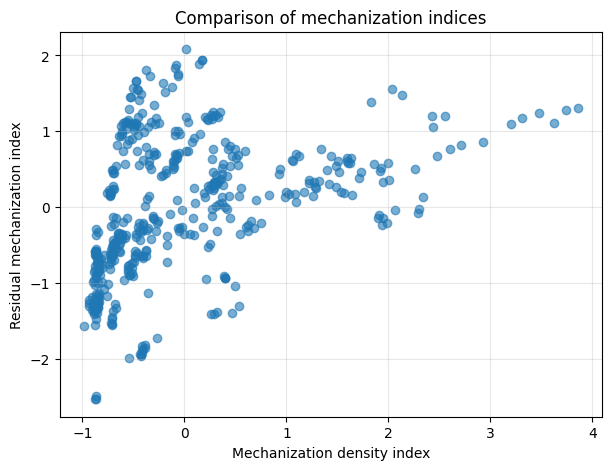

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(df["indice_mecanizare_densitate"], df["indice_mecanizare_rezidual"], alpha=0.6)
plt.xlabel("Mechanization density index")
plt.ylabel("Residual mechanization index")
plt.title("Comparison of mechanization indices")
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
df[["indice_mecanizare_densitate", "indice_mecanizare_rezidual"]].corr()

,indice_mecanizare_densitate,indice_mecanizare_rezidual
indice_mecanizare_densitate,1.000000,0.403942
indice_mecanizare_rezidual,0.403942,1.000000


- Both mechanization index specifications will be tested in the subsequent analyses.
- The correlation between the two indices is moderate, suggesting that they capture different dimensions of mechanization rather than measuring the same underlying construct.

###
SCATTERPLOTS MUNCA-MECANIZARE

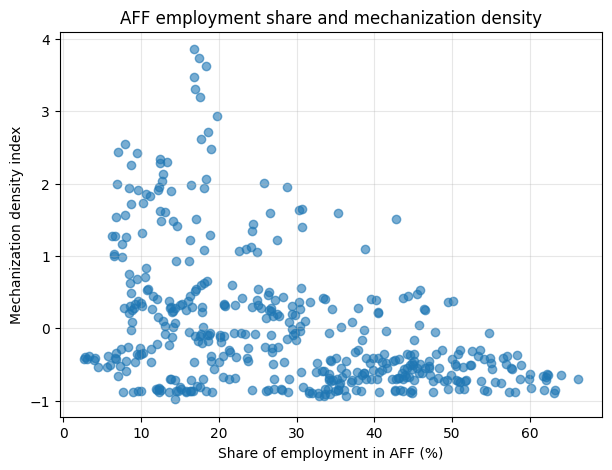

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(df["pondere_ocupati_aff_eurostat"], df["indice_mecanizare_densitate"], alpha=0.6)
plt.xlabel("Share of employment in AFF (%)")
plt.ylabel("Mechanization density index")
plt.title("AFF employment share and mechanization density")
plt.grid(True, alpha=0.3)
plt.show()

- The overall pattern is negative: as the share of AFF employment increases, the mechanization density index tends to decrease.

- The relationship appears to be non-linear. At lower levels of AFF employment, mechanization density varies substantially, while at higher levels of AFF employment, the mechanization index tends to be lower.



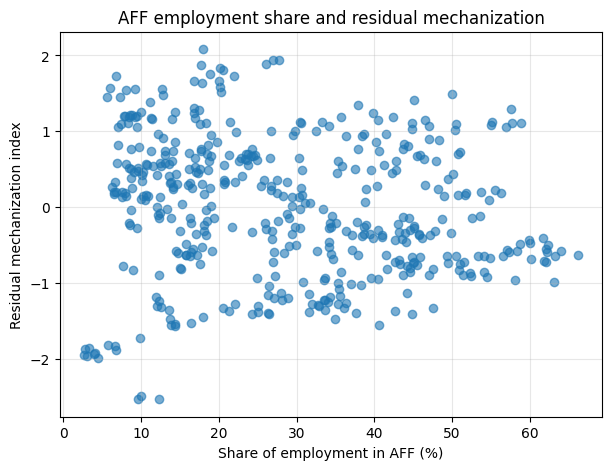

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(df["pondere_ocupati_aff_eurostat"], df["indice_mecanizare_rezidual"], alpha=0.6)
plt.xlabel("Share of employment in AFF (%)")
plt.ylabel("Residual mechanization index")
plt.title("AFF employment share and residual mechanization")
plt.grid(True, alpha=0.3)
plt.show()

- The overall relationship appears to be weakly negative.
- The association is relatively weak, with substantial dispersion across observations.

### EDA Based on County-Level Averages

In [24]:
county_summary = df.groupby("judet")[[
    "rata_emig_15_64",
    "rata_migratie_neta_15_64",
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "yield_soia_boabe",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]].mean().round(3)

In [25]:
county_summary.corr().round(2)

,rata_emig_15_64,rata_migratie_neta_15_64,pondere_ocupati_aff_eurostat,schimbare_pondere_ocupati_aff_eurostat,indice_mecanizare_densitate,indice_mecanizare_rezidual,yield_grau,yield_orz_orzoaica,yield_porumb_boabe,yield_floarea_soarelui,yield_rapita,yield_soia_boabe,temperatura_medie_anuala_C,precipitatii_anuale_mm,pondere_rurala
rata_emig_15_64,1.00,0.46,0.04,0.17,-0.07,-0.09,-0.02,-0.08,-0.19,-0.11,-0.16,-0.00,0.02,-0.16,-0.35
rata_migratie_neta_15_64,0.46,1.00,0.41,0.22,-0.22,-0.20,-0.32,-0.34,-0.33,-0.17,-0.36,-0.19,0.04,-0.39,0.17
pondere_ocupati_aff_eurostat,0.04,0.41,1.00,-0.49,-0.44,-0.16,-0.03,0.08,0.08,0.10,-0.11,0.03,0.29,-0.47,0.57
schimbare_pondere_ocupati_aff_eurostat,0.17,0.22,-0.49,1.00,0.32,-0.13,-0.30,-0.54,-0.12,-0.21,-0.18,-0.14,-0.53,0.13,-0.37
indice_mecanizare_densitate,-0.07,-0.22,-0.44,0.32,1.00,0.38,-0.28,-0.45,-0.16,-0.25,-0.10,-0.11,-0.71,0.73,-0.35
indice_mecanizare_rezidual,-0.09,-0.20,-0.16,-0.13,0.38,1.00,0.19,0.09,0.15,0.27,0.15,-0.21,-0.10,0.38,-0.14
yield_grau,-0.02,-0.32,-0.03,-0.30,-0.28,0.19,1.00,0.83,0.79,0.79,0.72,0.41,0.48,-0.19,-0.22
yield_orz_orzoaica,-0.08,-0.34,0.08,-0.54,-0.45,0.09,0.83,1.00,0.60,0.56,0.52,0.39,0.67,-0.27,-0.02
yield_porumb_boabe,-0.19,-0.33,0.08,-0.12,-0.16,0.15,0.79,0.60,1.00,0.76,0.68,0.51,0.17,-0.13,-0.07
yield_floarea_soarelui,-0.11,-0.17,0.10,-0.21,-0.25,0.27,0.79,0.56,0.76,1.00,0.70,0.33,0.32,-0.30,-0.06


- Migration shows only a very weak relationship with mechanization, with correlations of approximately -0.07 and -0.09.

- Agricultural employment is moderately negatively associated with the machinery density index (r = -0.44).

- The residual mechanization index may be more suitable for examining the relationship between mechanization and agricultural productivity. It shows weak positive correlations with crop yields, whereas the machinery density index shows negative correlations.

- Climate variables show strong correlations with machinery density: precipitation is positively correlated with the index (r = 0.73), while temperature is negatively correlated with it (r = -0.71). Temperature and precipitation are also strongly negatively correlated (r = -0.70).

### Missing Values by Crop

In [26]:
yield_cols = [
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "yield_rapita",
    "yield_soia_boabe"
]

df[yield_cols].isna().sum()

yield_grau                 0
yield_orz_orzoaica         0
yield_porumb_boabe         0
yield_floarea_soarelui    14
yield_rapita              27
yield_soia_boabe          50
dtype: int64

- Missing values are particularly frequent for rapeseed and soybean.

### Temporal Trends

In [27]:

# Variabile-cheie pentru trenduri
trend_vars = [
    "rata_emig_15_64",
    "rata_migratie_neta_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm"
]

# Medii anuale la nivel național/județean agregat
trend_df = (
    df.groupby("an")[trend_vars]
    .mean(numeric_only=True)
    .reset_index()
)

trend_df.head(11)

,an,rata_emig_15_64,rata_migratie_neta_15_64,pondere_ocupati_aff_eurostat,indice_mecanizare_densitate,yield_grau,yield_orz_orzoaica,yield_porumb_boabe,yield_floarea_soarelui,temperatura_medie_anuala_C,precipitatii_anuale_mm
0,2012,0.745461,0.324920,34.884506,-0.069345,2.579540,2.230683,2.201861,1.277425,10.259813,724.128346
1,2013,0.835810,0.564635,34.562832,-0.050619,3.363140,2.811594,4.380493,1.907605,10.293949,793.313029
2,2014,0.670154,1.423256,33.458607,-0.055345,3.541381,3.050731,4.701312,2.058715,10.404527,910.212472
3,2015,0.869667,0.415172,29.941324,-0.022011,3.568384,2.971924,3.371365,1.659101,10.724606,727.482612
4,2016,1.344593,0.253166,27.298633,0.003451,3.783137,3.286072,3.982563,1.874462,10.226039,890.851953
5,2017,1.318690,1.222018,26.797855,0.079032,4.523024,3.724236,5.815480,2.710971,10.029655,767.384387
6,2018,1.578368,1.692748,26.689292,0.043842,4.388459,3.915870,7.338490,2.840836,10.485185,790.494561
7,2019,1.593604,1.789842,25.739220,-0.010363,4.352885,3.682867,6.069478,2.727365,11.071002,695.200305
8,2020,1.261809,0.248834,25.030082,0.000722,3.098799,2.629532,4.148770,1.985694,10.975067,756.792295
9,2021,2.034370,0.306310,25.495431,0.022199,4.524844,3.863872,5.380615,2.392813,9.813598,817.570947


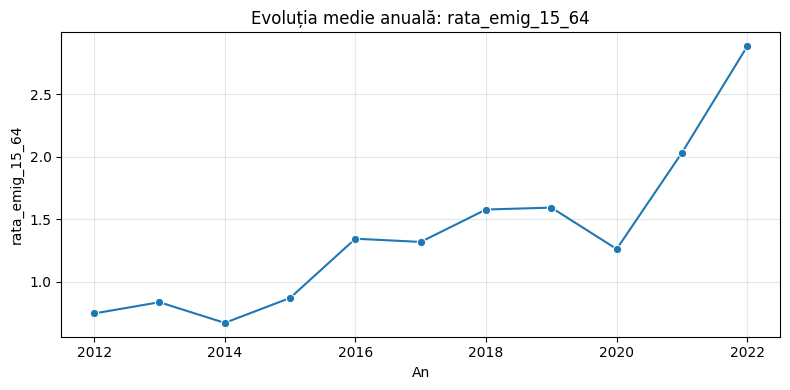

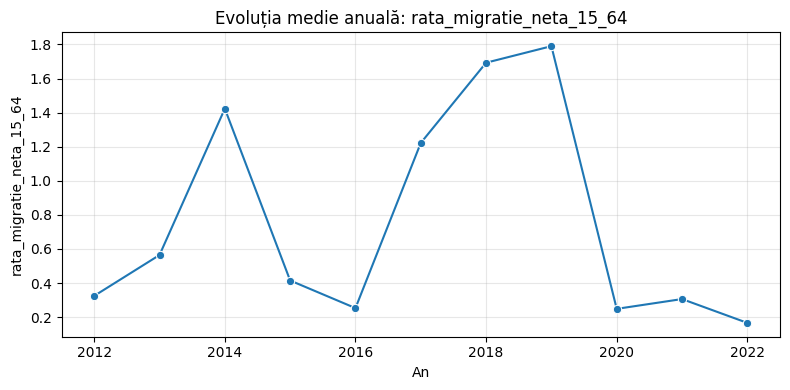

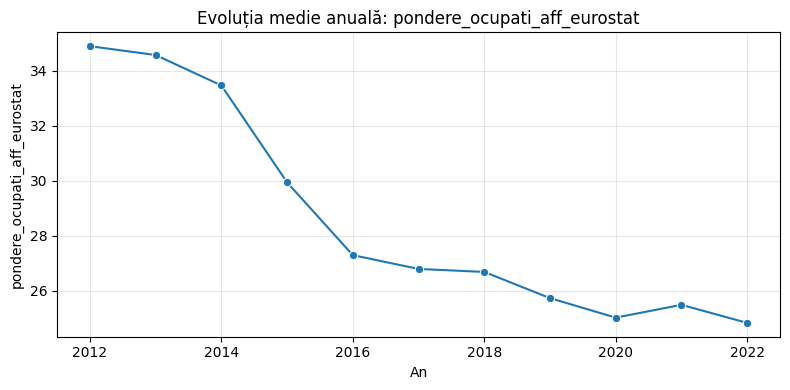

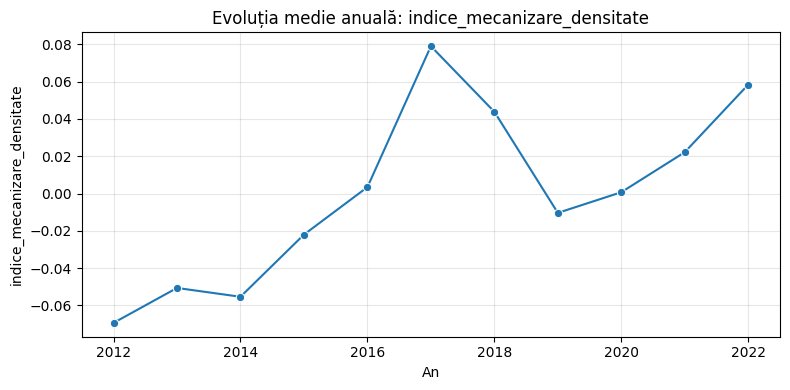

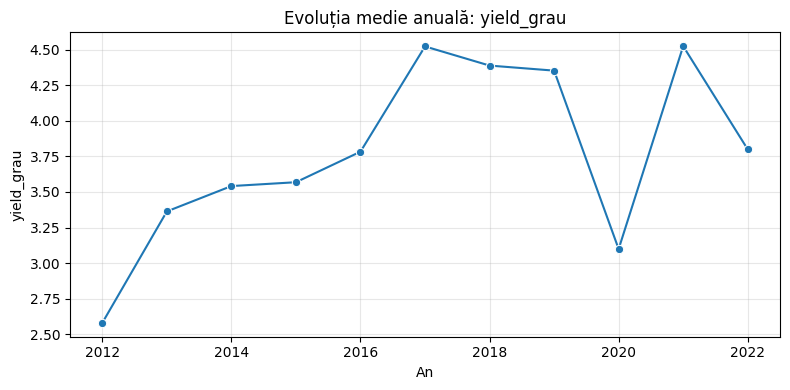

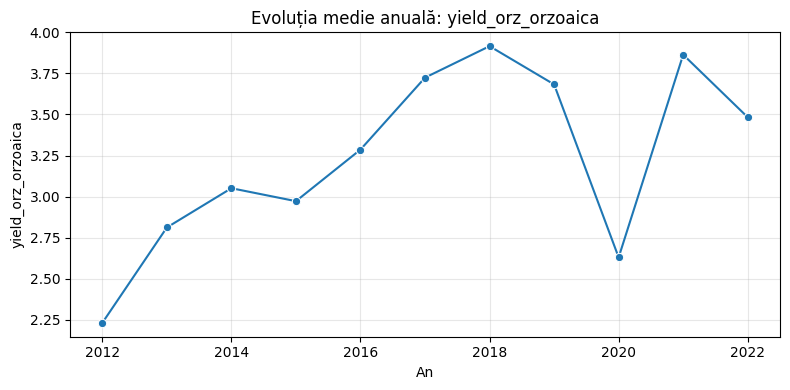

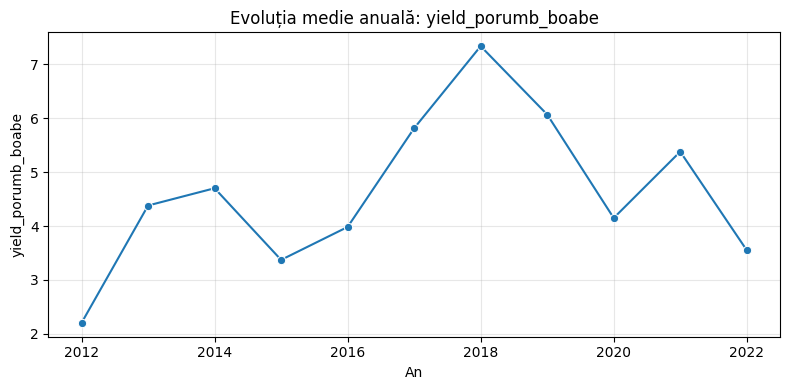

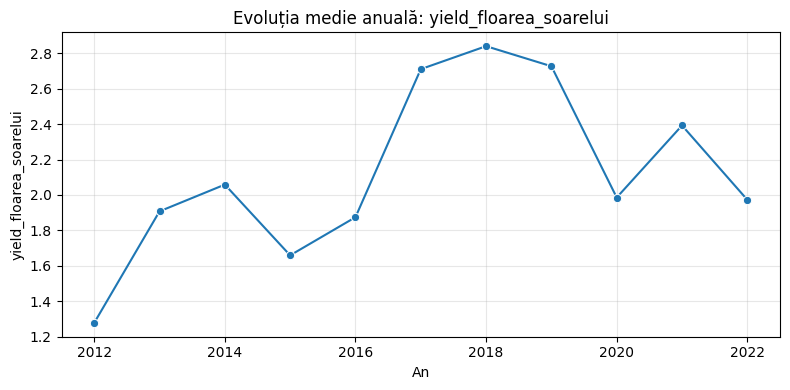

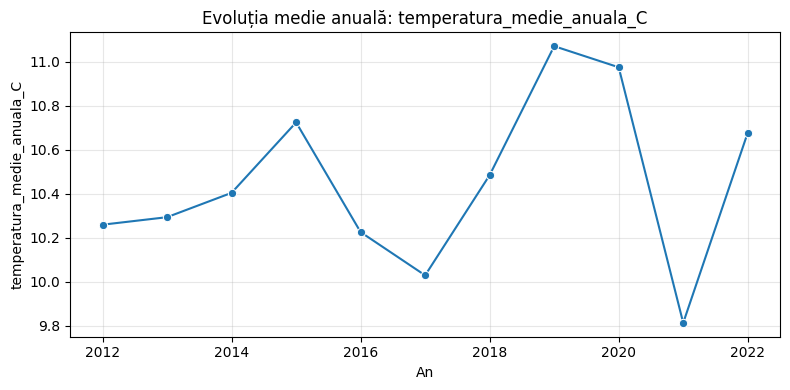

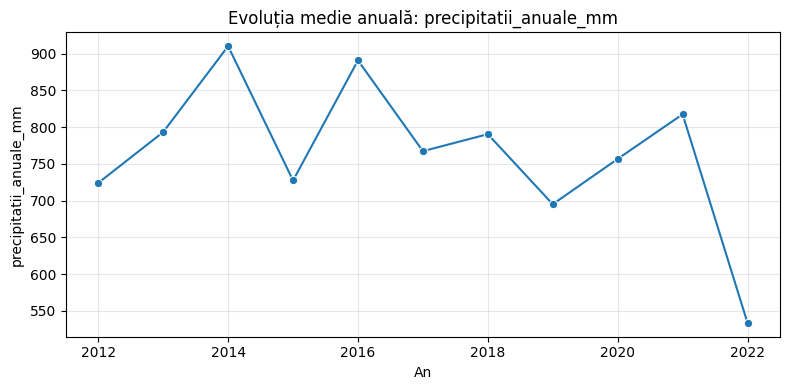

In [28]:
import seaborn as sns

for var in trend_vars:
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=trend_df, x="an", y=var, marker="o")
    plt.title(f"Evoluția medie anuală: {var}")
    plt.xlabel("An")
    plt.ylabel(var)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

- Over the analyzed period, the share of employment in agriculture, forestry, and fishing (AFF) shows a substantial decline, while the working-age emigration rate (15–64) increases and the machinery density index follows an overall upward trend.

- Crop yields do not follow a simple linear trend and instead show substantial year-to-year fluctuations. These patterns suggest that time-varying factors, including climatic conditions, should be considered in the subsequent analysis.

### Distributions and Outlier Analysis

In [29]:
eda_vars = [
    "rata_emig_15_64",
    "rata_migratie_neta_15_64",
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]

df[eda_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
rata_emig_15_64,451.0,1.376333e+00,0.960898,0.153051,0.767320,1.108827,1.748389,8.306831
rata_migratie_neta_15_64,451.0,7.643110e-01,5.217842,-3.940931,-0.961448,-0.531761,-0.200019,43.393908
pondere_ocupati_aff_eurostat,451.0,2.861250e+01,15.815452,2.730439,14.528335,26.848951,41.541864,66.144914
schimbare_pondere_ocupati_aff_eurostat,410.0,-1.004482e+00,2.510777,-13.004259,-2.255219,-0.899782,0.464342,8.567769
indice_mecanizare_densitate,451.0,1.773836e-11,0.930987,-0.980996,-0.683922,-0.354697,0.327038,3.856129
indice_mecanizare_rezidual,451.0,-9.846767e-18,0.907752,-2.530997,-0.646172,0.061402,0.674135,2.082357
yield_grau,451.0,3.774817e+00,0.884442,0.983083,3.195169,3.777532,4.401597,5.994879
yield_orz_orzoaica,451.0,3.240934e+00,0.943051,1.017149,2.605668,3.093537,3.856614,7.219444
yield_porumb_boabe,451.0,4.631103e+00,1.719827,0.252296,3.465615,4.476385,5.786776,10.420537
yield_floarea_soarelui,437.0,2.133286e+00,0.632567,0.427039,1.696705,2.137745,2.532534,3.916080


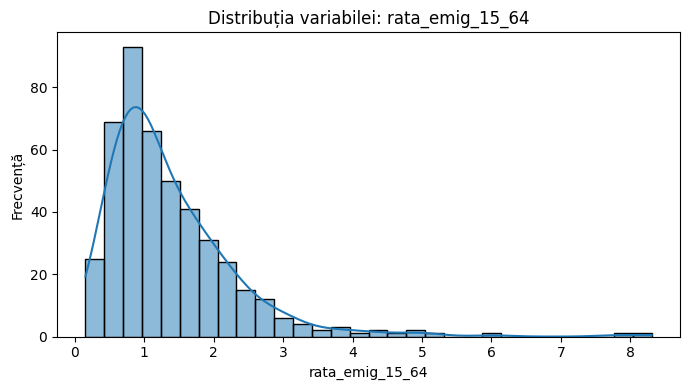

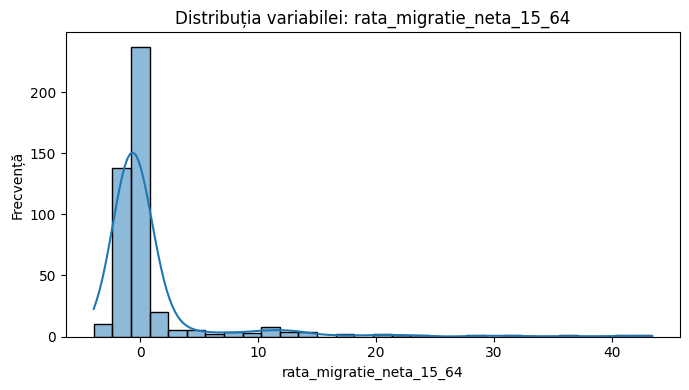

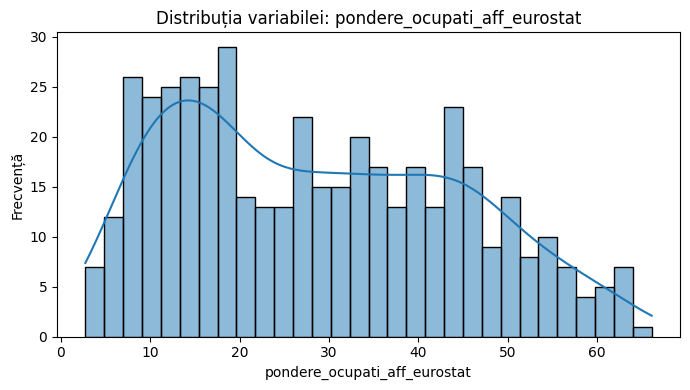

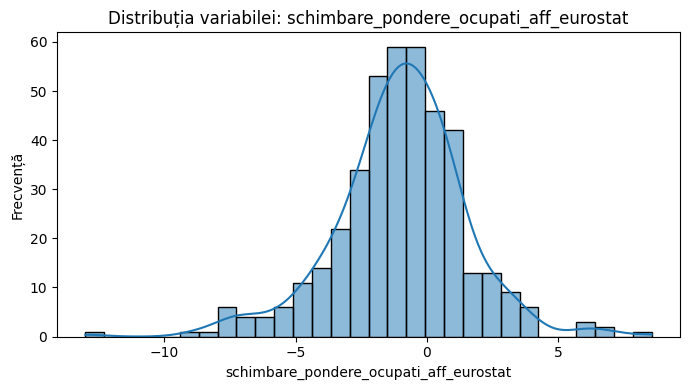

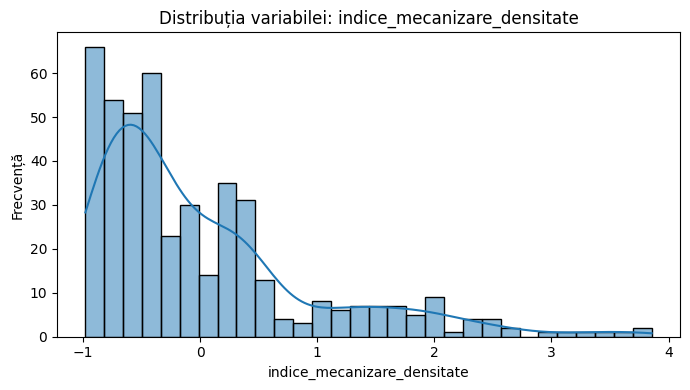

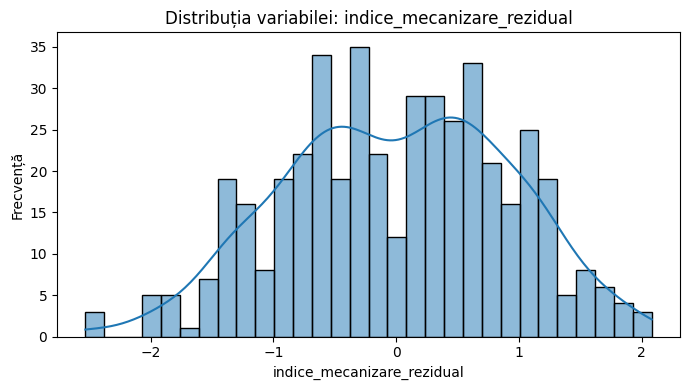

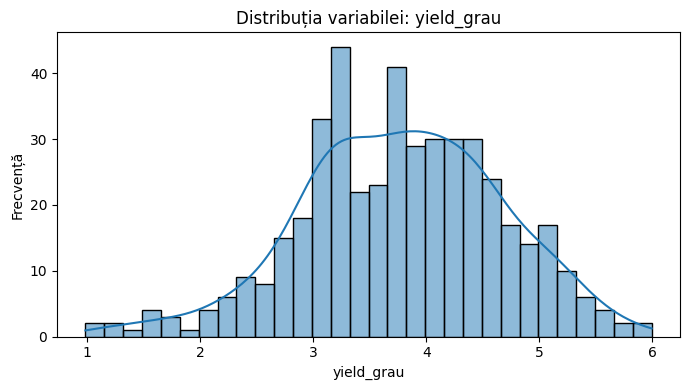

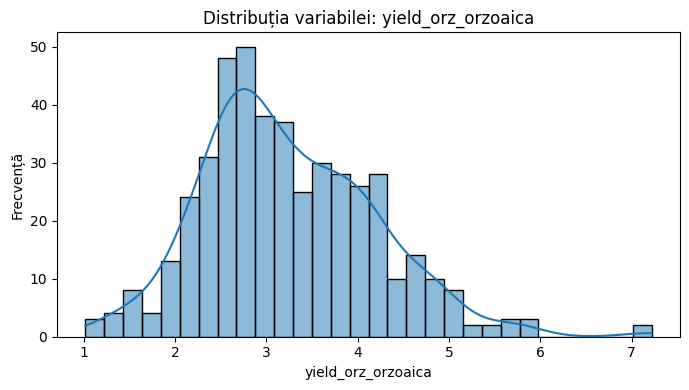

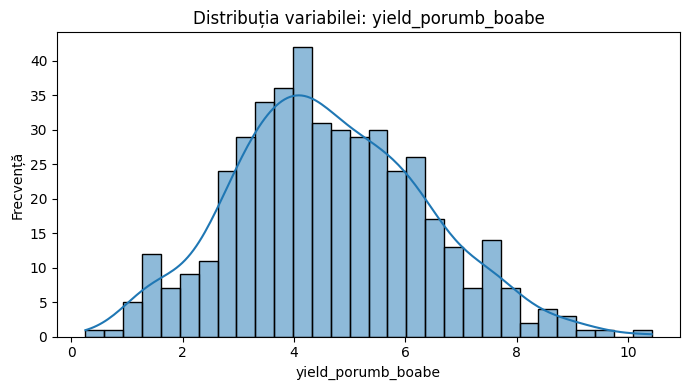

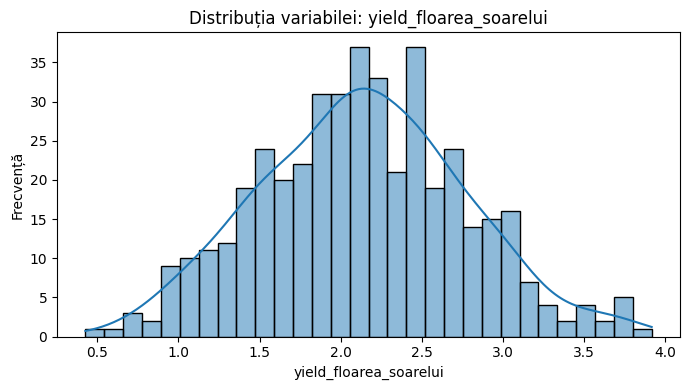

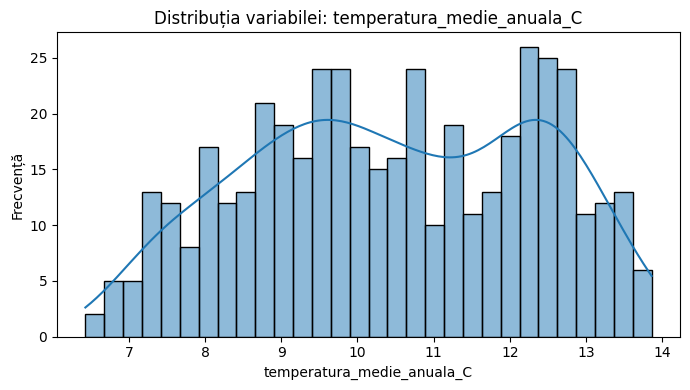

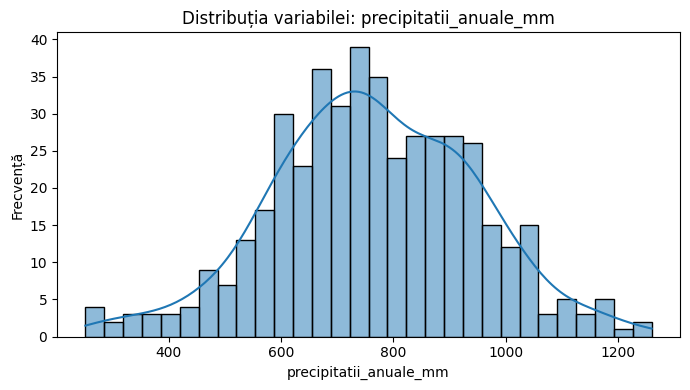

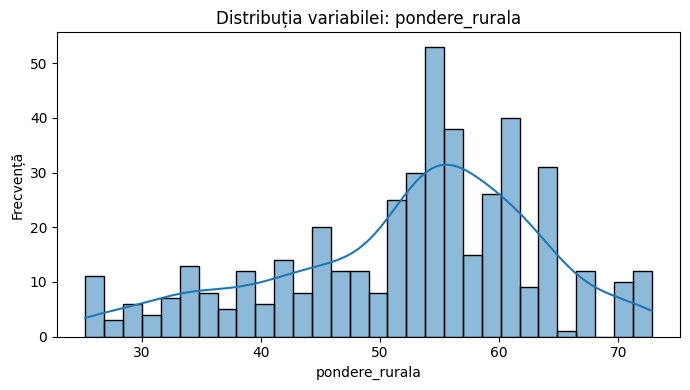

In [30]:
for var in eda_vars:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[var], kde=True, bins=30)
    plt.title(f"Distribuția variabilei: {var}")
    plt.xlabel(var)
    plt.ylabel("Frecvență")
    plt.tight_layout()
    plt.show()

In [31]:
#OUTLIERI MIGRATIE

df.loc[
    df["rata_migratie_neta_15_64"].abs().sort_values(ascending=False).head(20).index,
    ["an", "judet", "migratie_neta_15_64_nr", "populatie_15_64", "rata_migratie_neta_15_64"]
]

# MULTI IN ZONA VASLUI, MOLDOVA

,an,judet,migratie_neta_15_64_nr,populatie_15_64,rata_migratie_neta_15_64
436,2019,Vaslui,10065,231945,43.393908
435,2018,Vaslui,9484,235606,40.253644
434,2017,Vaslui,8567,239737,35.734993
439,2022,Vaslui,7180,231737,30.983399
431,2014,Vaslui,7200,248238,29.004423
255,2014,Iasi,12296,531446,23.136876
433,2016,Vaslui,5254,243245,21.599622
430,2013,Vaslui,5159,248460,20.763906
72,2018,Botosani,4961,244660,20.277119
73,2019,Botosani,4195,242340,17.310390


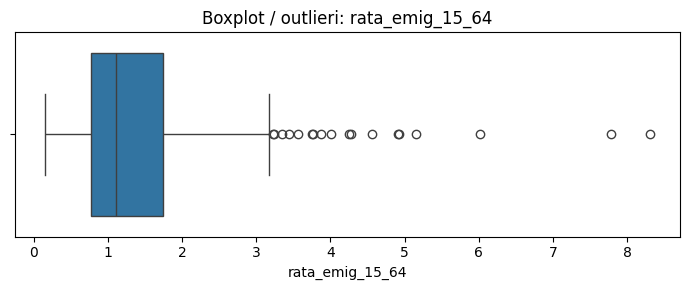

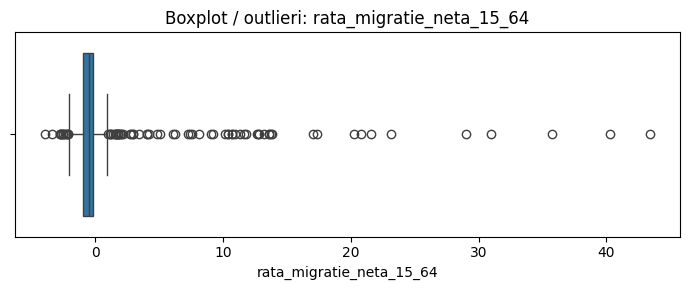

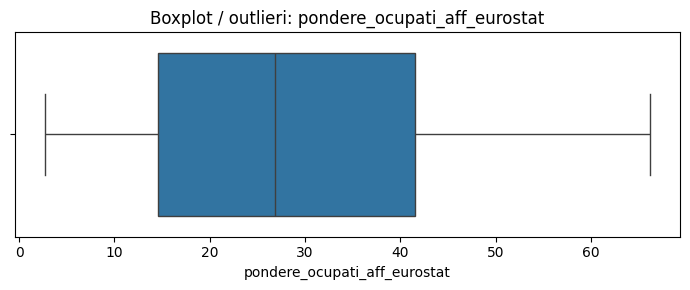

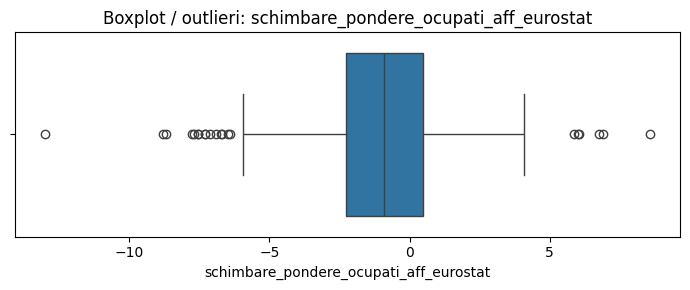

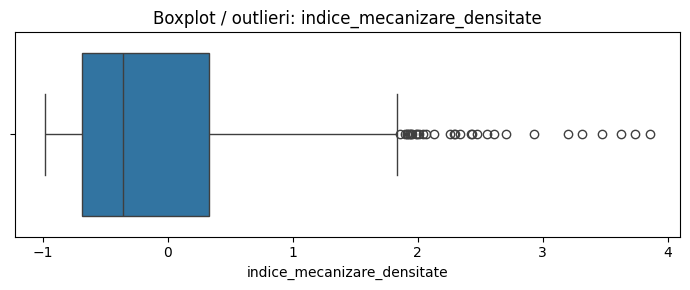

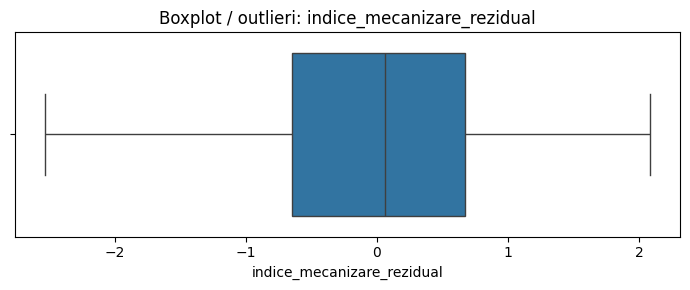

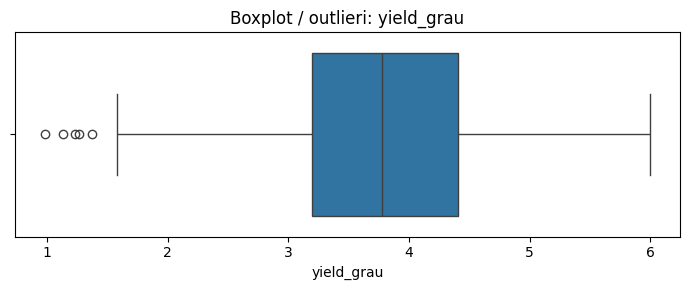

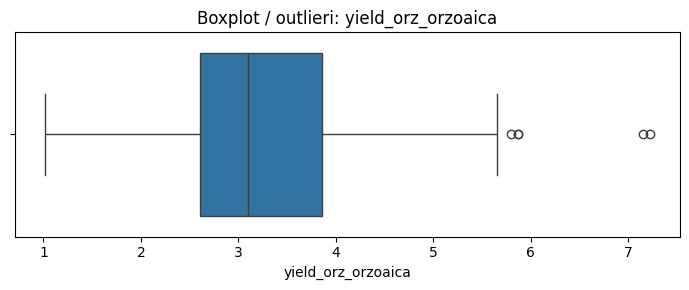

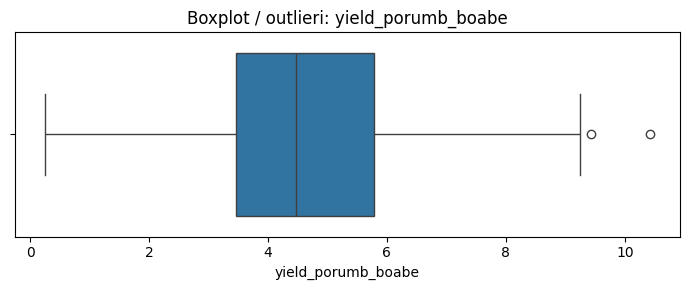

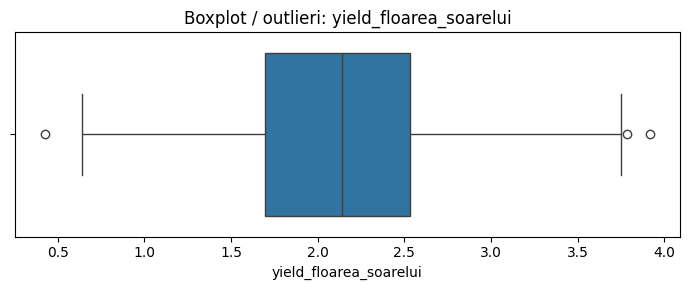

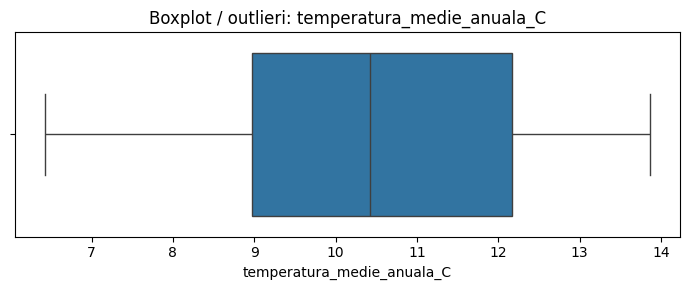

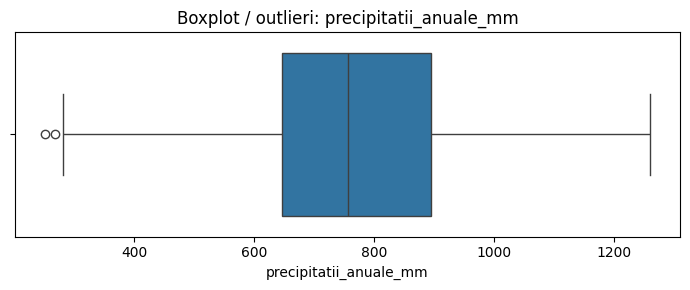

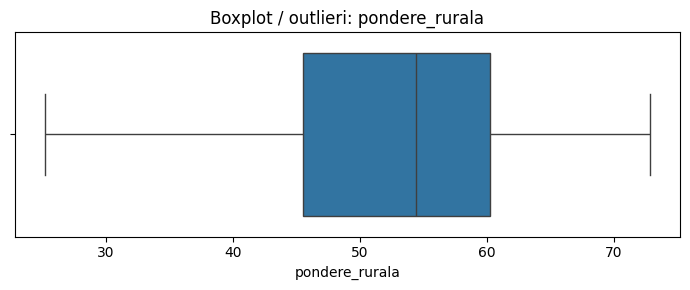

In [32]:
for var in eda_vars:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[var])
    plt.title(f"Boxplot / outlieri: {var}")
    plt.xlabel(var)
    plt.tight_layout()
    plt.show()

- **Emigration rate:** The distribution is right-skewed and contains several high-value outliers.

- **AFF employment share:** The distribution is relatively symmetric, with substantial variability across observations and no major outliers.

- **Annual change in AFF employment share:** Changes are generally moderate, although some county-year observations show relatively sharp variations.

- **Machinery density index:** The distribution is right-skewed and contains several high-value outliers. Most observations are concentrated approximately between -0.7 and 0.4, while a small number reach substantially higher values.

- **Residual mechanization index:** The distribution is more symmetric and shows no major outliers, suggesting that the structural adjustment reduces the influence of the extreme values observed in the density-based index.

In [33]:
df.sort_values("indice_mecanizare_densitate", ascending=False)[
    [
        "an", "judet", "indice_mecanizare_densitate",
        "sup_totala_cultivata_ha",
        "tractoare_1000ha", "pluguri_1000ha",
        "semanatori_1000ha", "combine_1000ha"
    ]
].head(20)

,an,judet,indice_mecanizare_densitate,sup_totala_cultivata_ha,tractoare_1000ha,pluguri_1000ha,semanatori_1000ha,combine_1000ha
285,2022,Maramures,3.856129,21996,519.185306,278.868885,50.327332,15.230042
284,2021,Maramures,3.740764,21794,508.534459,275.167477,49.050197,14.637056
280,2017,Maramures,3.626486,21391,457.108130,284.792670,47.496611,15.193306
283,2020,Maramures,3.475166,23140,468.366465,270.224719,45.808124,13.915298
282,2019,Maramures,3.311574,23390,443.138093,260.025652,44.121419,13.980333
281,2018,Maramures,3.199753,23975,430.698644,253.055266,43.295099,13.639208
230,2022,Harghita,2.927381,23205,475.026934,202.283990,32.148244,15.427710
278,2015,Maramures,2.708459,23118,382.472532,221.991522,35.340427,13.582490
279,2016,Maramures,2.609261,24020,368.109908,213.655287,36.011657,13.072440
241,2022,Hunedoara,2.550757,30163,303.053410,208.533634,37.960415,15.151013


In [34]:
def detect_outliers_iqr(data, variable):
    q1 = data[variable].quantile(0.25)
    q3 = data[variable].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[
        (data[variable] < lower_bound) |
        (data[variable] > upper_bound)
    ][["an", "judet", variable]]
    
    return outliers.sort_values(variable)

# Exemplu: outlieri pentru mecanizare
outliers_mecanizare = detect_outliers_iqr(df, "indice_mecanizare_densitate")
outliers_mecanizare

,an,judet,indice_mecanizare_densitate
91,2015,Brasov,1.854611
223,2015,Harghita,1.895414
228,2020,Harghita,1.911699
93,2017,Brasov,1.915468
94,2018,Brasov,1.931910
221,2013,Harghita,1.941644
276,2013,Maramures,1.949077
224,2016,Harghita,1.951538
220,2012,Harghita,1.983536
238,2019,Hunedoara,1.991651


In [35]:
outlier_summary = {}

for var in eda_vars:
    outliers = detect_outliers_iqr(df, var)
    outlier_summary[var] = len(outliers)

pd.Series(outlier_summary).sort_values(ascending=False)

rata_migratie_neta_15_64                  77
indice_mecanizare_densitate               31
schimbare_pondere_ocupati_aff_eurostat    21
rata_emig_15_64                           18
yield_grau                                 5
yield_orz_orzoaica                         5
yield_floarea_soarelui                     3
precipitatii_anuale_mm                     2
yield_porumb_boabe                         2
pondere_ocupati_aff_eurostat               0
indice_mecanizare_rezidual                 0
temperatura_medie_anuala_C                 0
pondere_rurala                             0
dtype: int64

- **Working-age net migration rate (15–64):** This variable shows the largest number of outliers and is therefore treated as a complementary migration indicator, while the working-age emigration rate is used as the main migration measure.

- **Machinery density index:** Positive outliers are concentrated in counties with relatively small cultivated areas. For this reason, results based on this index are interpreted alongside the residual mechanization index.

- **Crop yields and climate variables:** The main crop yield indicators and climate variables contain relatively few extreme observations and are retained without additional treatment.

### Climate, Mechanization, and Agricultural Productivity

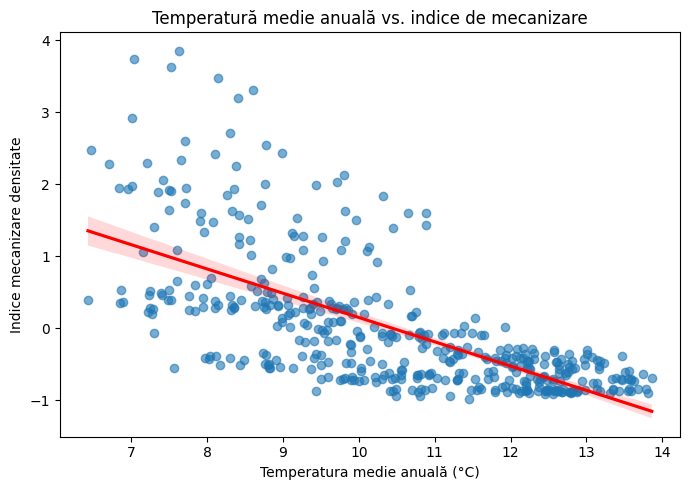

In [36]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="temperatura_medie_anuala_C",
    y="indice_mecanizare_densitate",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Temperatură medie anuală vs. indice de mecanizare")
plt.xlabel("Temperatura medie anuală (°C)")
plt.ylabel("Indice mecanizare densitate")
plt.tight_layout()
plt.show()

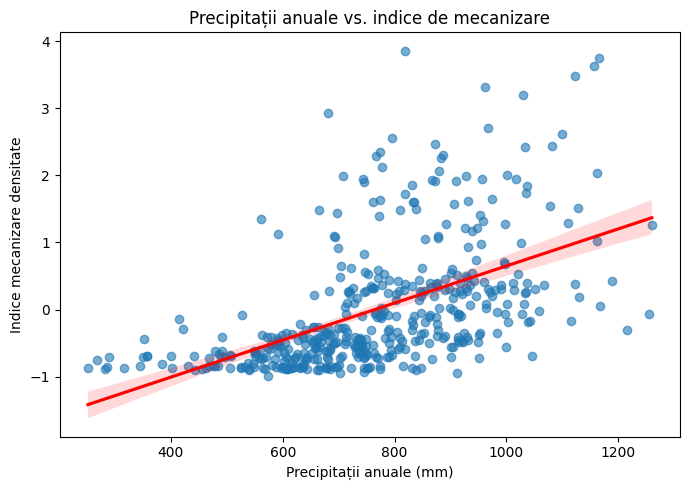

In [37]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="precipitatii_anuale_mm",
    y="indice_mecanizare_densitate",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Precipitații anuale vs. indice de mecanizare")
plt.xlabel("Precipitații anuale (mm)")
plt.ylabel("Indice mecanizare densitate")
plt.tight_layout()
plt.show()

- **Limitation of the machinery density index:** The index appears to be influenced by geographical and territorial structure, particularly differences in cultivated area across counties.

- **Temperature:** The machinery density index is negatively associated with temperature. Mountainous and sub-mountainous counties, which tend to have smaller cultivated areas, often show higher machinery density values.

- **Precipitation:** The index is positively associated with precipitation, with colder and wetter counties tending to display higher machinery density values.

- These patterns suggest that climate and territorial characteristics should be accounted for in the subsequent statistical models.

- The residual mechanization index will also be used to reduce the influence of cultivated-area differences and provide an alternative measure of mechanization.

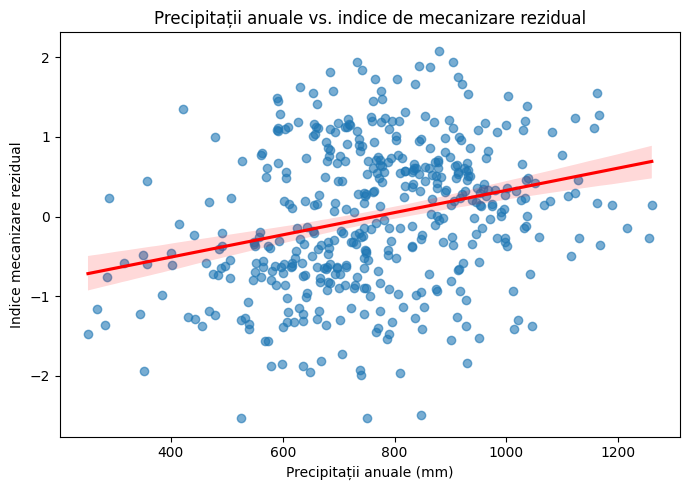

In [38]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=df,
    x="precipitatii_anuale_mm",
    y="indice_mecanizare_rezidual",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Precipitații anuale vs. indice de mecanizare rezidual")
plt.xlabel("Precipitații anuale (mm)")
plt.ylabel("Indice mecanizare rezidual")
plt.tight_layout()
plt.show()

- Compared with the machinery density index, the residual mechanization index shows a weaker relationship, with observations being more widely dispersed.

- The overall association remains positive, but is less pronounced.

### VIF

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

x_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]

X = df[x_vars].dropna()

vif_table = pd.DataFrame()
vif_table["variable"] = X.columns
vif_table["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_table

,variable,VIF
0,rata_emig_15_64,3.002609
1,pondere_ocupati_aff_eurostat,6.705376
2,indice_mecanizare_densitate,1.951930
3,temperatura_medie_anuala_C,24.924937
4,precipitatii_anuale_mm,16.868281
5,pondere_rurala,27.268755


In [40]:
x_vars_resid = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]

X = df[x_vars_resid].dropna()

vif_table_resid = pd.DataFrame()
vif_table_resid["variable"] = X.columns
vif_table_resid["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_table_resid

,variable,VIF
0,rata_emig_15_64,2.926807
1,pondere_ocupati_aff_eurostat,6.449487
2,indice_mecanizare_rezidual,1.082868
3,temperatura_medie_anuala_C,19.631133
4,precipitatii_anuale_mm,11.155429
5,pondere_rurala,27.695375


In [41]:
x_vars = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm"
]

X = df[x_vars].dropna()

vif_table = pd.DataFrame()
vif_table["variable"] = X.columns
vif_table["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_table

,variable,VIF
0,rata_emig_15_64,3.002034
1,pondere_ocupati_aff_eurostat,4.865559
2,indice_mecanizare_densitate,1.951919
3,temperatura_medie_anuala_C,19.438899
4,precipitatii_anuale_mm,14.305013


In [42]:
x_vars_resid = [
    "rata_emig_15_64",
    "pondere_ocupati_aff_eurostat",
    "indice_mecanizare_rezidual",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm"
]

X = df[x_vars_resid].dropna()

vif_table_resid = pd.DataFrame()
vif_table_resid["variable"] = X.columns
vif_table_resid["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_table_resid

,variable,VIF
0,rata_emig_15_64,2.926633
1,pondere_ocupati_aff_eurostat,4.656330
2,indice_mecanizare_rezidual,1.066182
3,temperatura_medie_anuala_C,14.230981
4,precipitatii_anuale_mm,8.310462


- After excluding the rural population share, VIF values decrease for most predictors, suggesting that this variable overlapped with the territorial structure captured by the other indicators.

- The mechanization indicators do not show substantial multicollinearity concerns, particularly the residual mechanization index, which has a VIF close to 1.

- Higher VIF values remain associated with the climate variables, indicating stronger overlap between these predictors.

### Missing Values

In [43]:
main_analysis_vars = [
    "an",
    "judet",
    "rata_emig_15_64",
    "rata_migratie_neta_15_64",
    "pondere_ocupati_aff_eurostat",
    "schimbare_pondere_ocupati_aff_eurostat",
    "indice_mecanizare_densitate",
    "indice_mecanizare_rezidual",
    "yield_grau",
    "yield_orz_orzoaica",
    "yield_porumb_boabe",
    "yield_floarea_soarelui",
    "temperatura_medie_anuala_C",
    "precipitatii_anuale_mm",
    "pondere_rurala"
]

missing_main = df[main_analysis_vars].isna().sum().sort_values(ascending=False)
missing_main

schimbare_pondere_ocupati_aff_eurostat    41
yield_floarea_soarelui                    14
judet                                      0
rata_emig_15_64                            0
rata_migratie_neta_15_64                   0
pondere_ocupati_aff_eurostat               0
an                                         0
indice_mecanizare_densitate                0
indice_mecanizare_rezidual                 0
yield_orz_orzoaica                         0
yield_grau                                 0
yield_porumb_boabe                         0
temperatura_medie_anuala_C                 0
precipitatii_anuale_mm                     0
pondere_rurala                             0
dtype: int64

In [44]:
missing_main_pct = (
    df[main_analysis_vars]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(2)
)

missing_main_pct

schimbare_pondere_ocupati_aff_eurostat    9.09
yield_floarea_soarelui                    3.10
judet                                     0.00
rata_emig_15_64                           0.00
rata_migratie_neta_15_64                  0.00
pondere_ocupati_aff_eurostat              0.00
an                                        0.00
indice_mecanizare_densitate               0.00
indice_mecanizare_rezidual                0.00
yield_orz_orzoaica                        0.00
yield_grau                                0.00
yield_porumb_boabe                        0.00
temperatura_medie_anuala_C                0.00
precipitatii_anuale_mm                    0.00
pondere_rurala                            0.00
dtype: float64